# TP: Introduction to an Image Processing Pipeline

### Name: **Vigier Eliott**

The objective of this TP is to play with a simple pipeline to "develop" a raw image into an image in JPEG format.

We will go through the following steps:
- Import and observe a raw image
- Linearization and exposure
- Demosaicing
- White balance
- Color Rendering
- Gamma compression
- Common image enhancements: saturation, contrast, sharpening

In a second stage, we will simulate the same pipeline with a simple simulation of noise and compare it to an image captured with high ISO.

The purpose of the TP is not for you to implement image processing but just to observe the effect of each steps and understand what is does.
Code is provided for each step, so that you can read and understand the concept of each processing at the pixel level.

Answer the questions below and then export the notebook with the answers using the menu option File->Download .ipynb. **[Then submit your solution here!](https://docs.google.com/forms/d/e/1FAIpQLScZqOU9T5Fuy021Z5-RXmmXFddjrnEyYX0gLsnPJ3EtV4akkg/viewform?usp=sharing)**


Install necessary modules:

In [ ]:
!pip install rawpy
!pip install imageio
!pip install scipy

Import necessary modules:

In [ ]:
import io, requests, rawpy
import imageio
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import numpy as np
import scipy.ndimage

In [ ]:
# The following lines install the necessary packages in the colab environment
try:
    from google.colab import files
    !pip install -q hdf5storage

    !rm -fr IspPipeline
    !git clone -b dataonly --single-branch --quiet https://github.com/DXOMARK-OCTO/IspPipeline
    !cp -r IspPipeline/* .

except ImportError:
    # %matplotlib notebook
    pass

%matplotlib inline

# Helper function for displaying images
def imshow(im, **kwargs):
  im = im / im.max()
  plt.figure(figsize=(8, 8))
  plt.imshow(im, **kwargs)
  plt.axis('off')
  plt.show()

# Import a Raw Image

In this section we will import a raw image from a DNG file.
DNG is a universal file format developped by Adobe for raw images.
It contains the raw data from the sensor as well as some metadata useful to transform the raw data to a viewable image.



In [ ]:
raw = rawpy.imread("./SonyA7S3/ISO100.dng")

A raw image contains raw data (pixels in bayer pattern) but also metadata to "develop" the image and a thumbnail.
Let's start by looking at the thumbnail:

In [ ]:
thumb_bytes = raw.extract_thumb().data
thumb_img = imageio.imread(thumb_bytes)
imshow(thumb_img)

Now let's extract the raw data and explore it.

In [ ]:
rh, rw = raw.sizes.raw_height, raw.sizes.raw_width
print(f"Raw image height and width: {rh}, {rw}")
img_raw = raw.raw_image.copy().astype(float)
print(f"Raw image min and max values: {img_raw.min()}, {img_raw.max()}")
print(f"Raw image average value: {img_raw.mean()}")
imshow(img_raw, cmap='gray')

Let's magnify the image to see the Bayer color filter array.

In [ ]:
imshow(img_raw[1842:1872, 1778:1820], cmap='gray')

Let's explore some of the metadata.

In [ ]:
bayer_pattern = raw.raw_pattern
print(f"Bayer pattern: {bayer_pattern}")
blc = raw.black_level_per_channel
print(f"Black level: {blc}")
wl  = raw.white_level
print(f"White level: {wl}")

The encoding of the Bayer pattern is as follows:
0 = Red, 1 = GreenTR for TopRight, 2 = Blue, 3 = GreenBL for Bottom Left.

This means that the pixel at the top left of the sensor in the Sony A7S3 is red, like this:

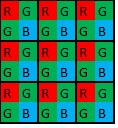

Without loss of generality, we suppose this Bayer configuration for the rest of this exercise.

# Linearization

Black level is an analog offset applied on the output of the photo diode. For now, all we need to know is that this offset must be removed to obtain a linear image, i.e. an image where gray levels are proportional to light intensity in each channel.

In the general case, the black level can be different for each channel. But for the Sony A7S3, as we have just observed, the value is the same for all channels.

Also, we find it convenient to normalize the pixel values such that 1.0 corresponds to pure white.

In [ ]:
bl = blc[0]  # same for all channels
img_lin = (img_raw - bl) / (wl - bl)
print(f"Min and max values after linearization: {img_lin.min()}, {img_lin.max()}")


### <font color='blue'> Question 0
Observe that we have negative values.
Can you explain why?

---
<font color='green'>  It is because of the noise generated by the hardware. It's important to retain these values because they provide insight into the noise distribution, which can be useful for image correction or further analysis.

---

For now we get rid of them.

In [ ]:
img_lin[img_lin < 0] = 0
print(f"Min and max values after linearization and clamp: {img_lin.min()}, {img_lin.max()}")

# Exposure

In this section we will adjust the target exposure with a global gain on the raw image.

As we have explained in the lecture, exposure is adjusted right in the sensor, via shutter and ISO speed, even before the image is captured. For reasons that we will explain during the lecture about color, many cameras intentionally underexpose the images. The Sony A7S3 that we use for this exercise underexposes by approximately 2 "stops", i.e. by a factor of 4. We start by applying this coefficient.

In [ ]:
img_expo = (4 * img_lin).clip(0, 1)

# Demosaicing

In this section we will apply demosaicing to the image.



## Assign Colors to Pixels

To get started, we assign the observed pixel values to their corresponding channels, based on their position.

In [ ]:
def isp_split_colors(img_in) -> np.ndarray:
  h, w = img_in.shape
  img_out = np.zeros((h, w, 3))
  # Red
  img_out[0::2, 0::2, 0] = img_in[0::2, 0::2]
  # Green
  img_out[1::2, 0::2, 1] = img_in[1::2, 0::2]
  img_out[0::2, 1::2, 1] = img_in[0::2, 1::2]
  # Blue
  img_out[1::2, 1::2, 2] = img_in[1::2, 1::2]
  return img_out

img_split = isp_split_colors(img_expo)
imshow(img_split[1842:1872, 1778:1820])

## Bilinear Interpolation

Next we apply naive bilinear interpolation as best guess for all the missing pixels. To interpolate missing G values on red and blue pixels, we use the four closest neighbors. To interpolate missing R and B values on green pixels, we use the two closest vertical or horizontal neighbors.

In [ ]:
def isp_bilinear_demosaicing(img_in) -> np.ndarray:
  kernel_G  = np.array([[0, 0.25, 0], [0.25, 1, 0.25], [0, 0.25, 0]])
  kernel_RB = np.array([[0.25, 0.5, 0.25], [0.5, 1, 0.5], [0.25, 0.5, 0.25]])
  img_out = np.empty_like(img_in)
  img_out[:, :, 0] = scipy.ndimage.correlate(img_in[:, :, 0], kernel_RB, mode='mirror')
  img_out[:, :, 1] = scipy.ndimage.correlate(img_in[:, :, 1], kernel_G , mode='mirror')
  img_out[:, :, 2] = scipy.ndimage.correlate(img_in[:, :, 2], kernel_RB, mode='mirror')
  return img_out

img_dem_bil = isp_bilinear_demosaicing(img_split)
imshow(img_dem_bil[1842:1872, 1778:1820])
imshow(img_dem_bil[1502:1532, 1878:1920])

### <font color='blue'> Question 1
How many different filters are necessary to make a bilinear demosaicing algorothm?
Explain how the above code works, and particularly why we can implement the bilinear demosaicing with only 2 filters.


---
<font color='green'>  To implement bilinear demosaicing, only two filters are needed: one for the green channel (kernel_G) and one for the red and blue channels (kernel_RB). This works because the raw data is composed of 0s and 1s, representing the absence or presence of color information at each pixel.

<font color='green'> These binary values allow the interpolation to function correctly, filling in missing color data. If the data were not binary, the filters wouldn't work as expected, since the interpolation relies on the specific arrangement of zeros and ones in the Bayer pattern to reconstruct the full color image.


---



## Advanced Demosaicing

Finally we attempt to design a more sophisticated demosaicing algorithm.

Remember that we're basically just guessing the values we did not observe. The question is, what values are plausible? Writing a demosicing algorithm means formulating a strategy for finding plausible values, exploiting supposed properties of the photographed scene.

Our above linear interpolation strategy supposes that the photographed scene does not contain any "sudden" spatial variations. This heuristic is correct for the vast majority of pixels, but wrong for pixels on sharp edges (observe the "zipper" artifact).

To better restore edges and high frequencies, we introduce two heuristics:
- The scene is entirely composed of horizontal and vertical edges. Rather than using all four nearest neighbors for interpolating missing green pixels, we only use the two that follow the direction of the edge.
- Spatial variations at the pixel level are identical in all color channels. High frequencies that we observe in the green channel (where the Bayer pattern has twice more pixels) can be transposed in the red and blue channels.

Based on these heuristics, we propose the following algorithm:
- On each missing green pixel, compute horizontal and vertical linear interplation.
- Among the two interpolations, select the one that leads to minimum variation in its direction. This step yields a fully interpolated G channel.
- On each pixel where R or B were observed, compute respectively ΔR = R–G and ∆B = B–G.
- Compute ∆R and ∆B for pixels where red and blue have not been observed, using linear interpolation.
- Obtain fully interpolated R and B channels by adding the fully interpolated ∆R and ∆B to the fully interpolated G.

In [ ]:
def isp_advanced_demosaicing(img_in) -> np.ndarray:
  img_out = np.empty_like(img_in)
  h, w, _ = img_in.shape
  # Compute two proposals for G
  kernel_dir = np.array([0.5, 1.0, 0.5])
  green_H = scipy.ndimage.correlate1d(img_in[:, :, 1], kernel_dir, axis=1, mode='mirror')
  green_V = scipy.ndimage.correlate1d(img_in[:, :, 1], kernel_dir, axis=0, mode='mirror')
  # Compute variation and select best proposal for G
  kernel_var  = np.array([-1, 0, 1])
  var_H = np.abs(scipy.ndimage.correlate1d(green_H, kernel_var, axis=1, mode='mirror'))
  var_V = np.abs(scipy.ndimage.correlate1d(green_V, kernel_var, axis=0, mode='mirror'))
  img_out[:, :, 1] = (var_H > var_V).choose(green_H, green_V)
  # Compute deltaR and deltaB
  deltaR = np.zeros((h, w))
  deltaR[0::2, 0::2] = img_in[0::2, 0::2, 0] - img_out[0::2, 0::2, 1]
  deltaB = np.zeros((h, w))
  deltaB[1::2, 1::2] = img_in[1::2, 1::2, 2] - img_out[1::2, 1::2, 1]
  # Linear interpolation for deltaR and deltaB
  kernel_RB = np.array([[0.25, 0.5, 0.25], [0.5, 1, 0.5], [0.25, 0.5, 0.25]])
  deltaR = scipy.ndimage.correlate(deltaR, kernel_RB, mode='mirror')
  deltaB = scipy.ndimage.correlate(deltaB, kernel_RB, mode='mirror')
  # Compute R and B
  img_out[:, :, 0] = (img_out[:, :, 1] + deltaR).clip(0, 1)
  img_out[:, :, 2] = (img_out[:, :, 1] + deltaB).clip(0, 1)

  return img_out

img_dem_adv = isp_advanced_demosaicing(img_split)
imshow(img_dem_adv[1842:1872, 1778:1820])
imshow(img_dem_adv[1502:1532, 1878:1920])

# White Balance

In this section we will correct the white balance and try the most simple automatic white balance algorithm.

Color consistency, also called chromatic adaptation, is the brain's ability to neutralize the spectrum of the ambient light.

White balance, which mimicks this physiological aspect, consists in applying gains on Blue and Red channels to neutralize objects that reflect all the spectrum without absorption, also known as objects of gray color.

Automatic White Balance (AWB) is the name of the algorithm which tries to guess this blue and red gains.

## As-Shot White Balance

White balance gains resulting from camera AWB algorithm are part of the metadata.

In [ ]:
# Let's extract the white balance gain from the metadata. We name it White Balance As Shot.
wb_as_shot = np.array(raw.camera_whitebalance)[:3]
print(f"White balance gain from camera AWB: {wb_as_shot}")

In [ ]:
# Show the image before and after the white balance.
imshow(img_dem_adv[900:1650, 2300:3050])
img_wb_as_shot = img_dem_adv * wb_as_shot
imshow(img_wb_as_shot[900:1650, 2300:3050])

## Auto White Balance

Methods that estimate the white balance gain are called auto white balance algorithms, and can be very sophisticated (semantic interpretation of the scene via AI, use of additionnal sensors to observe the spectrum of the ambient light, etc...)

A naive classic but surprisingly effective such algorithm is called gray-world white balancing and relies on the gray world assumption, which states that the scene, on average, is gray. The gray-world assumption holds if we have a good distribution of colors in the scene. Assuming that the scene, on average, is gray, the reflected color, on average, is the color of the light source. Therefore, we can estimate the illumination color cast by looking at the average color and comparing it to gray.

## <font color='blue'> Exercise 1

Estimate the white balance gains using the gray-world assumption.

In [ ]:
########################
# use the img_dem_adv image and write white balance gain into wb_auto
wb_auto_grey_world = 1 / np.mean(img_dem_adv,axis=(0,1))

wb_auto_grey_world = wb_auto_grey_world / wb_auto_grey_world[1] # ajust green channel

#########################
print(f"White balance gains using the gray-world assumption: {wb_auto_grey_world}")

In [ ]:
img_wb_auto = img_dem_adv * wb_auto_grey_world
imshow(img_wb_auto[900:1650, 2300:3050])

As you can see, the results are rather close. Nevertheless the camera's more sophisticated auto white balance is superior: it correctly neutralizes the white background of the stripe patterns, while it remains a bit blueish using the gray-world assumption.

# Color Rendering

In this section we will play on the color rendering by applying a color matrix and adjust the saturation of colors.

## Color Matrix

A color matrix is a 3×3 matrix applied to the vector of (R, G, B).

\begin{matrix}
\begin{bmatrix}
    R_{out} \\
    G_{out} \\
    B_{out}
\end{bmatrix} =
\begin{bmatrix}
    m_{11} & m_{12} & m_{13} \\
    m_{21} & m_{22} & m_{23} \\
    m_{31} & m_{32} & m_{33}
\end{bmatrix}
\begin{bmatrix}
    R_{in} \\
    G_{in} \\
    B_{in}
\end{bmatrix}
\end{matrix}

The goal of the matrix is to modulate the color rendering. This is a very simple way of altering the colors.
More sophisiticated ones are used in modern cameras.

Color Matrix can be used to reach fidelity, or saturate more the colors, or give a particular signature to the colors.

All the difficulty resides in finding the good matrix.

Color Matrix resulting from camera color tuning is part of the metadata.

In [ ]:
color_matrix = raw.color_matrix[0:3,0:3]
print(f"Color matrix: {color_matrix}")

While the matrix has 9 coefficients, by convention it must change neither exposure nor white balance. In other words, gray pixels (where R=G=B) must remain unchanged. This means that the sum of each row must be equal to one. Thus, the matrix has actually only 6 degrees fo freedom.

Let's verify this property:

In [ ]:
print(f"Color matrix row sum: {color_matrix.sum(axis=1)}")

Now let's apply the matrix to the image and look at the result.

In [ ]:
def isp_apply_matrix(img_in, color_matrix) -> np.ndarray:
  # function that a apply a 3x3 matrix on each RGB pixel
  return np.dot(img_in, color_matrix.T).clip(0, 1)

# Apply the color rendering matrix and Observe a crop of the result
img_cm = isp_apply_matrix(img_wb_as_shot, color_matrix)
imshow(img_cm[900:1650, 2300:3050])

Observe that the colors are more vivid, more saturated than before.

# Color Artifacts

After applying white balance and color matrix, we observe that something is wrong. Look at all these reddish color artifacts on the high frequency stripe patterns.

### <font color='blue'> Exercise 2

What is wrong in our processing pipeline? Hint: it's related to one of the assumtions in our demosaicing algorithm.

Propose a fix and implement it.

In [ ]:
#########################
## Write Code here using only the isp_advanced_demosaicing function and the application of the wb_as_shot or wb_grey_world white balance ######
#########################
img_wb = isp_advanced_demosaicing(img_split * wb_as_shot)

img_cm = isp_apply_matrix(img_wb, color_matrix)
# Observe a crop of the result
imshow(img_cm[900:1650, 2300:3050])

# Gamma Compression

Until now our image is still linear, i.e. the graylevels are proportional to the amount of light received by the sensor. However, this is not what screens and operating systems expect. They expect the image to be non-linear, with a so-called gamma compression applied.

In order to faithfully reproduce the brightness and contrast of the scene on screen, we must apply such a gamma compression.

In [ ]:
def isp_apply_gamma(img_in) -> np.ndarray:
  # function that apply a gamma function
  return img_in ** (1/2.2)

# Apply the gamma compression est observe the image before and after:
img_gamma = isp_apply_gamma(img_cm)
imshow(img_cm)
imshow(img_gamma)

# Common Image Enhancements

The above image has received all essential processing steps. But probably it will not receive a lot of likes when posted on social networks, because it does not "pop". Let's apply some basic image enhancements to make the image more exciting.

## Color Saturation

We would like to play with the saturation of colors.

Let's first understand what would be an image without colors: this would be an image with the same color on each channel.

This corresponds to a matrix of the following form:

\begin{matrix}
\begin{bmatrix}
    R_{out} \\
    G_{out} \\
    B_{out}
\end{bmatrix} =
\begin{bmatrix}
    m_{r2gray} & m_{g2gray} & m_{b2gray} \\
    m_{r2gray} & m_{g2gray} & m_{b2gray} \\
    m_{r2gray} & m_{g2gray} & m_{b2gray}
\end{bmatrix}
\begin{bmatrix}
    R_{in} \\
    G_{in} \\
    B_{in}
\end{bmatrix}
\end{matrix}

We want the lightness of the resulting image to be identical to the original image.
A simple way to achieve this is to have the sum of the coefficients of each line to be equal to one.
Setting each coefficient to $1/3$ is simple but doesn’t work as well as expected. The reason is that human vision is most sensitive to green light, less sensitive to red light, and the least sensitive to blue light. Therefore, the three colors should have different weights in the distribution.

The following weights comes from the analog television standards and are commonly used to convert RGB values to Y (or Luma) gray levels:

$Y = 0.299R + 0.587G + 0.114B$

In [ ]:
# Convert the image to Gray
gray_matrix = np.array([
  [0.299, 0.587, 0.114],
  [0.299, 0.587, 0.114],
  [0.299, 0.587, 0.114]
])

img_gray = isp_apply_matrix(img_gamma, gray_matrix)

imshow(img_gray)

An intuitive but effective way to play with the saturation of colors is to interpolate/extrapolate between the gray_matrix matrix and the Identity Matrix.

### <font color='blue'> Exercise 3

Write a function that generates a saturation adjustment matrix according to a parameter.

In [ ]:
def make_sat_matrix(sat_param) -> np.ndarray:
    #########################
    ## Write Code here ######
    #########################
    return (1 - sat_param) * gray_matrix +  sat_param * np.eye(3)


# Compute the saturation matrix for a coefficient of 1.5, apply the matrix and look at the result:
sat_matrix = make_sat_matrix(1.5)
img_sat = isp_apply_matrix(img_gamma, sat_matrix)
imshow(img_sat)

## Global Contrast

The global contrast in the image, i.e. the respective levels of shadows and highlights, can be adjusted via a transfer function. An S-curve is a simple way to adjust the contrast.

It is usually implemented with a Look-Up Table.

In [ ]:
def isp_apply_LUT(img_in, LUT) -> np.ndarray:
  N = len(LUT)
  return LUT[(img_in * N).astype(int).clip(0, N-1)]

Let's code a simple S-curve LUT with a sinus.

In [ ]:
N = 1024
t = np.linspace(0, 1 - 1/N, N)
LUT_sine = (np.sin(t * np.pi - np.pi / 2) + 1) / 2

plt.plot(LUT_sine)
plt.show()

In [ ]:
img_contrast = isp_apply_LUT(img_sat, LUT_sine)

imshow(img_contrast)

You can observe that the increase in contrast has further increased the color saturation.

## Unsharp Mask

In this section we will see a classical method to improve the perceptual sharpness of the image.


In photography, acutance describes a subjective perception of sharpness that is related to the edge contrasts in an image. Lenses act naturally as low pass filters and smooth the fine details, or high spatial frequencies, in an image.

Various techniques can be used to increase the acutance, or make the image look sharper.

Unsharp masking (USM) is an image sharpening technique, first implemented in darkroom photography, but now commonly used in digital image processing software. Its name derives from the fact that the technique uses a blurred, or "unsharp", negative image to create a mask of the original image.

$sharpened = original + (original − blurred) × amount$

In [ ]:
def isp_blur(img_in, sigma):
  # function that apply a low pass filter
  return scipy.ndimage.gaussian_filter(img_in, [sigma, sigma, 0], mode="nearest")


# Apply a low pass and look at the result:
img_blur = isp_blur(img_contrast, sigma=3)

imshow(img_contrast[900:1650, 2300:3050])
imshow(img_blur[900:1650, 2300:3050])

### <font color='blue'> Exercise 4

Write a function that applies an unsharp mask with a strength parameter as input.

In [ ]:
def isp_usm(img_in, sigma, strength) -> np.ndarray:
    #########################
    ## Write Code here ######
    #########################
    return np.clip(img_in + (img_in - isp_blur(img_in, sigma)) * strength, 0, 1)

# Apply the unsharp mask and look at the result:
img_sharp = isp_usm(img_contrast, sigma=3, strength=0.5)
imshow(img_sharp[900:1650, 2300:3050])

Now our image is ready to receive some oohs and aahs!

# Philosophical Note

At the beginning of this course we introduced two assumptions about the world and stated that they are true in most cases:
- The image contains no sudden spatial variations (thus we can use bilinear interpolation for demosaicing).
- The world is gray (thus we can use the average of each channel to compute the white balance scales).

Then, in order to make the image more "interesting" for the human eye:
- We emphasized sudden spatial variations (sharpening).
- We made the image less gray (more colorful via saturation, more distinct black or white via contrast).

Are these two in contradiction? Not at all. According to Claude Shannon's information theory, "the less probable an event is, the more surprising it is and the more information it yields." From an evolutionary point of view it makes totally sense that our visual system pays more attention to images that violate assumptions that are commonly true.





# Noise Simulation

In this section we will simulate photonic noise.
Let's first import a clean version of the isp-pipeline.


In [ ]:
try:
    !rm -fr IspPipeline
    !git clone --quiet https://github.com/DXOMARK-OCTO/IspPipeline
    !cp -r IspPipeline/* .
except ImportError:
    pass

import isp

In [ ]:
# Helper function for displaying images
def imshow(im, **kwargs):
  im = im / im.max()
  plt.imshow(im, **kwargs)
  plt.axis('off')

## Noise on real images

Let's observe the noise on a crop for two ISO settings of a camera shooting the exact same scene.

Reminder: when capturing an image, one can play on several parameters:

- Exposure Time
- Aperture of the Lens
- ISO sensitivity. The ISO sensitivity can be considered as an Gain (/100) applied to the analog signal just after photon to electron conversion.

Here are the capture settings for the following images:
- ISO6400.dng, gain is x64, exposure time is 1/6400, Aperture is F/3.2.
- ISO100.dng, gain is x1, exposure time is 1/100, Aperture is F/3.2.

In [ ]:
rawISO100 = rawpy.imread("SonyA7S3/ISO100.dng")
rawISO6400 = rawpy.imread("SonyA7S3/ISO6400.dng")

bp = rawISO100.raw_pattern
blc = rawISO100.black_level_per_channel
wl  = rawISO100.white_level
wb = np.array(rawISO100.camera_whitebalance)
cm = rawISO100.color_matrix[0:3,0:3]
print(f"bayer_pattern: {bp}")
print(f"Black Level: {blc}")
print(f"White Level: {wl}")
print(f"White Balance: {wb}")
print(f"Color Matrix: {cm}")

In [ ]:
cropRawISO100 = np.array(rawISO100.raw_image.copy()).reshape((rawISO100.sizes.raw_height, rawISO100.sizes.raw_width)).astype('float')[900:1300,1950:2350]
cropRawISO6400 = np.array(rawISO6400.raw_image.copy()).reshape((rawISO100.sizes.raw_height, rawISO6400.sizes.raw_width)).astype('float')[900:1300,1950:2350]

cropIspISO100 = isp.isp2(cropRawISO100, bp, blc, 2, wb[:3], cm, wl)
cropIspISO6400 = isp.isp2(cropRawISO6400, bp, blc, 2, wb[:3], cm, wl)

In [ ]:
plt.figure(figsize=(24, 24))

plt.subplot(2, 2, 1)
imshow(cropRawISO100, cmap='gray')
plt.title('RAW ISO 100')

plt.subplot(2, 2, 2)
imshow(cropRawISO6400, cmap='gray')
plt.title('RAW ISO 6400')

plt.subplot(2, 2, 3)
imshow(cropIspISO100)
plt.title('Full Pipe ISO 100')

plt.subplot(2, 2, 4)
imshow(cropIspISO6400)
plt.title('Full Pipe ISO 6400')

plt.show()

## Photonic (Poisson) Noise simulation

The sensor used is a Sony A7sIII which has been characterized. https://www.dxomark.com/Cameras/Sony/A7SIII---Measurements

We read that the SNR at 10% gray level is 42dB.



### Question 5

Can you estimate the full well capacity in photons with the following hypothesis?

We make the following assumption:
- photon to electron conversion is 100% efficient.
- the sensor is linear
- noise regime is purely photonic at 10% grey level (RAW data) ISO 100.

---
<font color='green'>**ANSWER TO QUESTION 5** </font>
$$
N_{10\%} = \frac{10 FW}{100} = \frac{FW}{10}
$$
$$
\text{SNR} = \sqrt{N_{10\%}} = 10^{\frac{42}{20}}
$$
$$
N_{10\%} = \left( 10^{\frac{42}{20}} \right)^2 = 15 848,9319
$$
$$
FW = 10 \times N_{10\%} = 158489,319 \quad photons
$$
---


### Question 6

Let's consider that the noise is neglectible in the image at ISO 100.
Given the image at ISO100 (Gain 1), a fullWell for the sensor of 158kphotons, and exposure Time T, simulate photonic noise for an image at gain G and an exposure of T/G:

In [ ]:
# Write is a function that simulates photonic noise starting from a picture


# you can use the np.random.poisson function.
def photonicNoise(img_in, blackLevel, whiteLevel, gain) -> np.ndarray :
  h, w = img_in.shape
  img_out = img_in.copy().flatten()

  #---------
  grayLevelToPhoton = 158000 / whiteLevel

  for index, val in enumerate(img_out):
    photonPerPixel = (val-blackLevel)*grayLevelToPhoton / gain
    img_out[index] = np.random.poisson(photonPerPixel)/grayLevelToPhoton * gain + blackLevel

  img_out[img_out < 0] = 0
  img_out = img_out.reshape((h, w))

  return img_out


cropRawISO6400Simulation = photonicNoise(cropRawISO100, blc[0], wl, 64)
cropIspISO6400Simulation = isp.isp2(cropRawISO6400Simulation, bp, blc, 2, wb[:3], cm, wl)

In [ ]:
plt.figure(figsize=(24, 24))

plt.subplot(2, 2, 1)
imshow(cropRawISO6400Simulation, cmap='gray')
plt.title('RAW ISO 6400 Simulation')

plt.subplot(2, 2, 2)
imshow(cropRawISO6400, cmap='gray')
plt.title('RAW ISO 6400')

plt.subplot(2, 2, 3)
imshow(cropIspISO6400Simulation)
plt.title('Full Pipe ISO 6400 Simulation')

plt.subplot(2, 2, 4)
imshow(cropIspISO6400)
plt.title('Full Pipe ISO 6400')

plt.show()

## Signal to Noise Ratio

We want to estimate the signal to noise ratio to quantify the amount of noise in the image.
Let's first choose a uniform crop such as this one:

In [ ]:
outimg = cropIspISO6400Simulation.copy()
h, w, c = outimg.shape
outimg[outimg < 0] = 0
outimg[outimg > 1] = 1
imshow(outimg)
plt.axis('off')
plt.title('Full Pipe ISO 6400 Simulation')
ax = plt.gca()

# Create a Rectangle patch
rect = patches.Rectangle((320, 225), 50, 50, linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()

outimg = cropIspISO6400Simulation[225:275,320:370].copy()
h, w, c = outimg.shape
outimg[outimg < 0] = 0
outimg[outimg > 1] = 1
imshow(outimg)
plt.axis('off')
plt.show()

### Question 7
Write a function that measure the signal to noise ratio on a uniform crop:

In [ ]:
# Write is a function that compute the signal to noise ratio on a crop.
def measureNoise(crop_in):
  #---------
  # Write Code Here
  #---------
  mean_value = np.mean(crop_in)
  std_dev = np.std(crop_in)
  snr = 20 * np.log10(mean_value / std_dev) if std_dev != 0 else float('inf')

  print(f"Mean:{mean_value}")
  print(f"Std Dev:{std_dev}")
  print(f"SNR : {snr} dB")

measureNoise(cropIspISO6400Simulation[225:275,320:370])
measureNoise(cropIspISO6400[225:275,320:370])